In [ ]:
!pip install transformers faiss-cpu pillow pandas tqdm --quiet


In [ ]:
# 1. Полностью убрать googletrans и переустановить httpx с нуля
!pip uninstall -y googletrans httpx httpx2 --quiet

# 2. Поставить чистый набор зависимостей (без googletrans)
!pip install transformers faiss-cpu pillow pandas tqdm deep-translator --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.3 MB/s eta 0:00:00


In [30]:
from google.colab import files
uploaded = files.upload()   # выберите clip_zero_shot_search.py в диалоге

Saving query.jpg to query.jpg


In [ ]:
import json
import pandas as pd

with open('/content/data/annotations/captions_val2017.json') as f:
    coco = json.load(f)

df = pd.DataFrame(coco['annotations'])[['image_id', 'caption']]
df = df.rename(columns={'caption': 'caption_en'})
df.to_csv('/content/data/captions.csv', index=False)
print(df.shape)
df.head()

(25014, 2)


,image_id,caption_en
0,179765,A black Honda motorcycle parked in front of a ...
1,179765,A Honda motorcycle parked in a grass driveway
2,190236,An office cubicle with four different types of...
3,331352,A small closed toilet in a cramped space.
4,517069,Two women waiting at a bench next to a street.


In [ ]:
from deep_translator import GoogleTranslator
print(GoogleTranslator(source="ru", target="en").translate("собака играет в снегу"))

dog playing in the snow


In [ ]:
!python clip_zero_shot_search.py build \
    --images_dir /content/data/images \
    --captions_csv /content/data/captions.csv \
    --index_dir /content/index

Индексирую файлы в /content/data/images (включая подпапки)...
Найдено файлов изображений: 5000
Загрузка модели openai/clip-vit-base-patch32 на cuda...
Loading weights: 100% 398/398 [00:00<00:00, 38229.58it/s]
Эмбеддинги изображений: 100% 157/157 [00:48<00:00,  3.24it/s]
Эмбеддинги текстов: 100% 782/782 [00:16<00:00, 47.40it/s]
Готово: 5000 изображений, 25014 подписей -> /content/index


In [ ]:
!python clip_zero_shot_search.py text \
    --index_dir /content/index \
    --query "собака в снегу" \
    --translate \
    --top_k 5

Переведённый запрос: dog in the snow
Загрузка модели openai/clip-vit-base-patch32 на cuda...
Loading weights: 100% 398/398 [00:00<00:00, 10203.56it/s]
Эмбеддинги текстов: 100% 1/1 [00:00<00:00,  4.34it/s]

Топ-5 изображений по запросу: "dog in the snow"
1. image_id=117645  score=0.2750  path=/content/data/images/val2017/000000117645.jpg
2. image_id=512836  score=0.2750  path=/content/data/images/val2017/000000512836.jpg
3. image_id=431727  score=0.2630  path=/content/data/images/val2017/000000431727.jpg
4. image_id=80153  score=0.2616  path=/content/data/images/val2017/000000080153.jpg
5. image_id=109992  score=0.2579  path=/content/data/images/val2017/000000109992.jpg
Коллаж с результатами сохранён: /content/index/search_result_text.png


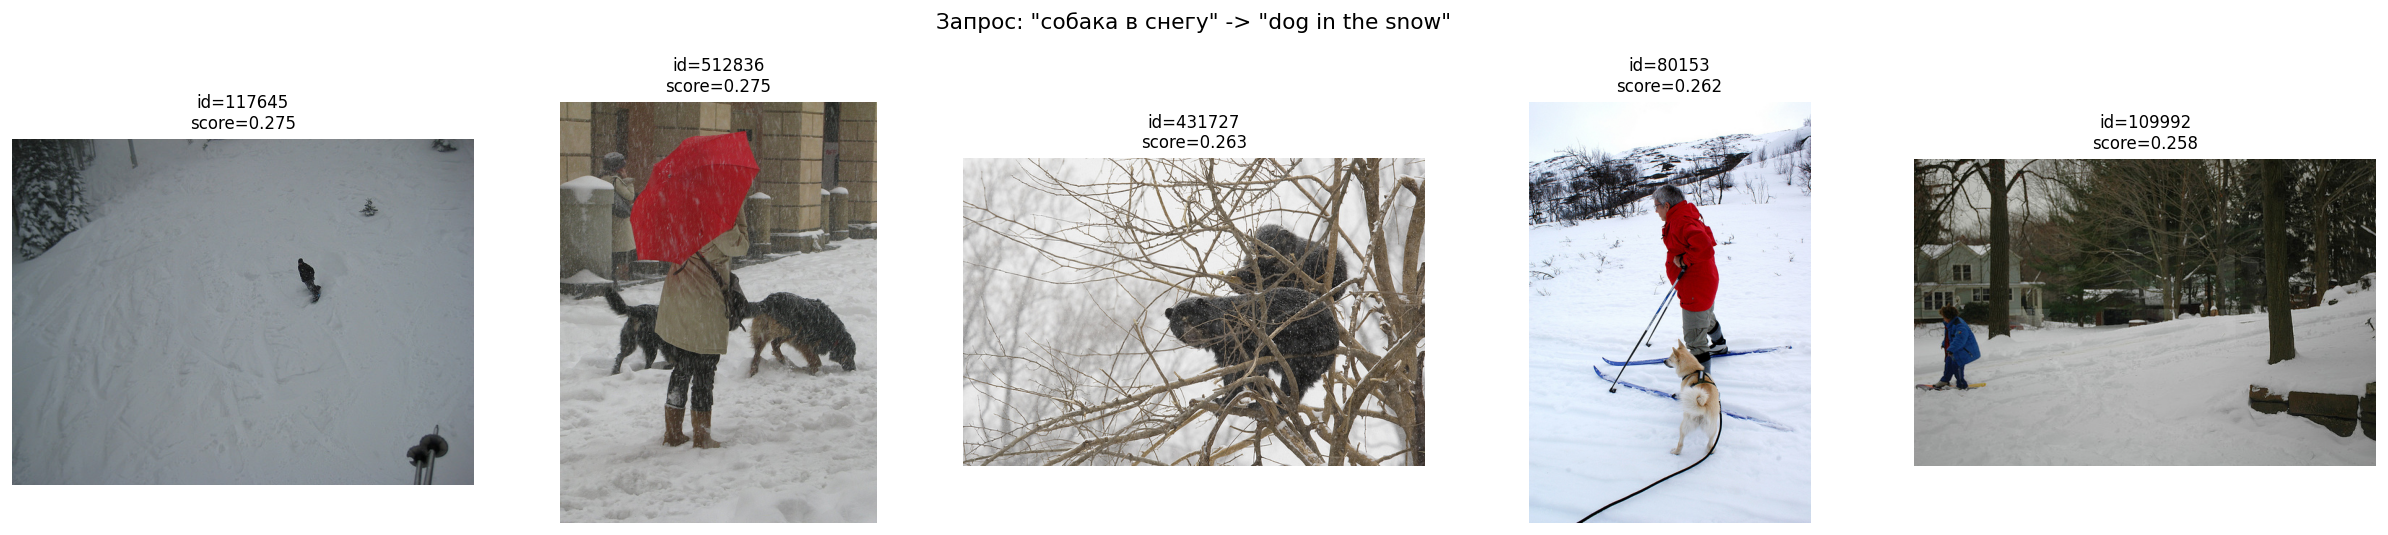

In [ ]:
from IPython.display import Image as IPImage, display
display(IPImage('/content/index/search_result_text.png'))

Загрузка модели openai/clip-vit-base-patch32 на cuda...
Loading weights: 100% 398/398 [00:00<00:00, 33192.81it/s]

Топ-5 похожих изображений:
1. image_id=65485  score=0.7028  path=/content/data/images/val2017/000000065485.jpg
2. image_id=297147  score=0.6920  path=/content/data/images/val2017/000000297147.jpg
3. image_id=97679  score=0.6855  path=/content/data/images/val2017/000000097679.jpg
4. image_id=488385  score=0.6730  path=/content/data/images/val2017/000000488385.jpg
5. image_id=266400  score=0.6615  path=/content/data/images/val2017/000000266400.jpg
Коллаж с результатами сохранён: /content/index/search_result_image.png

Топ-5 релевантных подписей:
1. image_id=459634  score=0.2713  caption="A back end of a vehicle with a metal rack and an antennae."
2. image_id=53529  score=0.2592  caption="a person in a car sits next to a top with a hat on"
3. image_id=368335  score=0.2580  caption="From the rear, we see a horse standing between two cars parked in a parking lot."
4. image_id=4

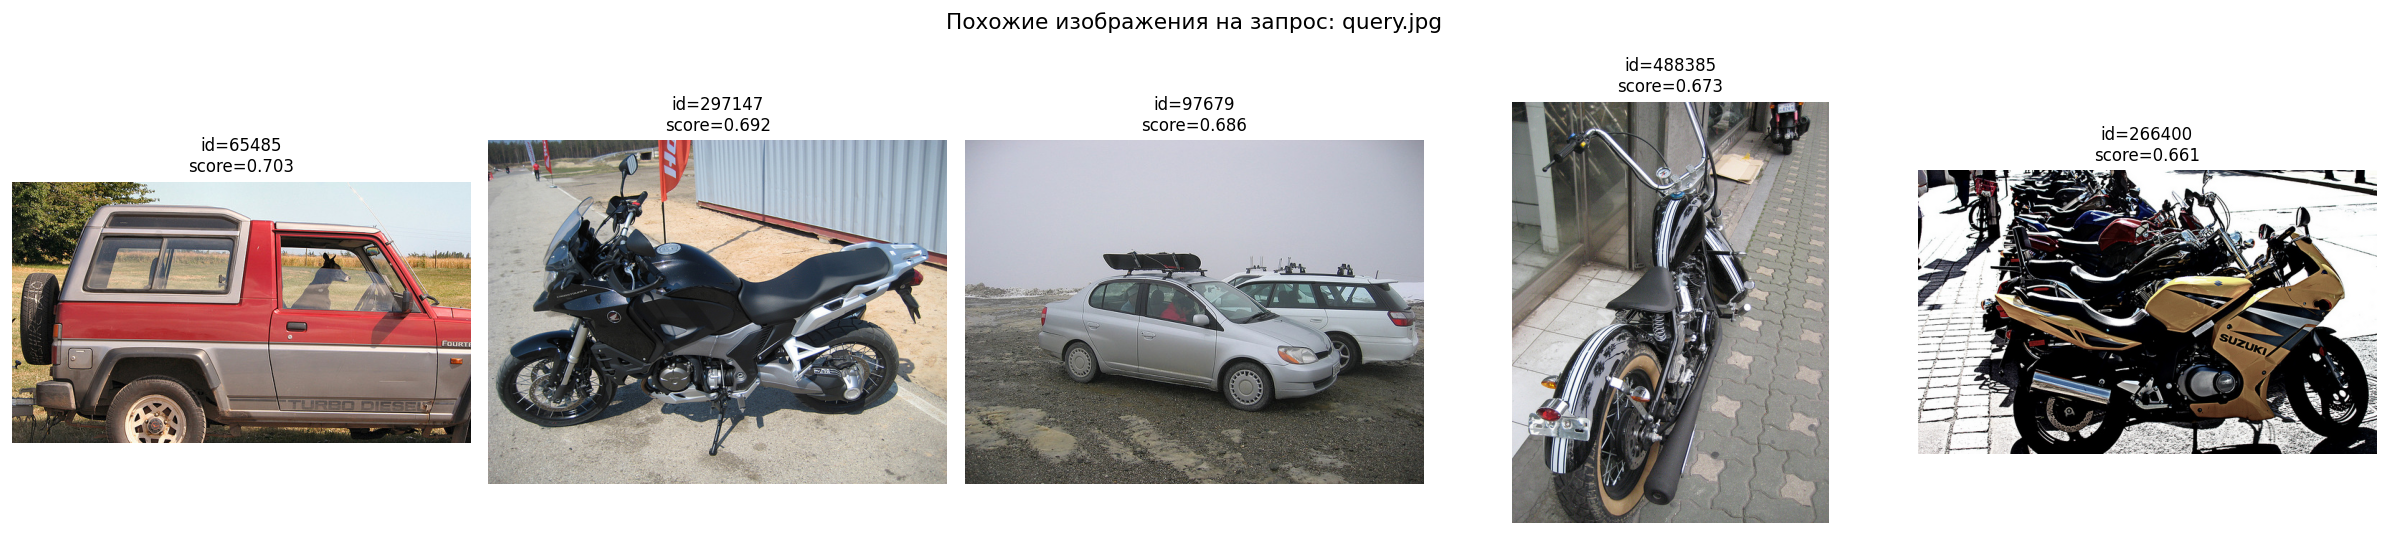

In [31]:
!python clip_zero_shot_search.py image \
    --index_dir /content/index \
    --image_path /content/query.jpg \
    --top_k 5

display(IPImage('/content/index/search_result_image.png'))

In [ ]:
!wget -q http://images.cocodataset.org/zips/val2017.zip
!wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip -q val2017.zip -d /content/data/images
!unzip -q annotations_trainval2017.zip -d /content/data

checkdir:  cannot create extraction directory: /content/data/images
           No such file or directory


In [ ]:
!unzip -q val2017.zip -d /content/data/images
